# Baseline LightGBM — Fraud Detection

A deliberately **simple baseline** to establish a reference score before any feature engineering.

- **Minimal features** known at transaction time (no leakage): `amt`, `category`, `gender`, `city_pop`, `hour`, `age`.
- **Leakage-safe split**: the same chronological 80/20 split used in the EDA notebook (train strictly precedes test in time).
- **Class imbalance** (~0.5% fraud) handled with `scale_pos_weight = n_negative / n_positive`, computed from the **training** set only.

Everything downstream (feature engineering, tuning) should be measured against the numbers produced here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

## 1. Load data & reproduce the chronological split

We only read the columns the baseline needs. The two raw CSVs are concatenated, sorted by transaction time, and split 80/20 chronologically — identical to `01_eda_time_split.ipynb`, so train ends before test begins.

In [2]:
# Only load the columns required for the baseline + the split + the target
USECOLS = [
    "trans_date_trans_time",
    "amt",
    "category",
    "gender",
    "city_pop",
    "dob",
    "is_fraud",
]

train_raw = pd.read_csv("../data/fraudTrain.csv", usecols=USECOLS)
test_raw = pd.read_csv("../data/fraudTest.csv", usecols=USECOLS)

df = pd.concat([train_raw, test_raw], ignore_index=True)
df["trans_dt"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"] = pd.to_datetime(df["dob"])

print(f"Combined dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

Combined dataset: 1,852,394 rows x 8 columns


In [3]:
# Sort by time, then 80/20 chronological split (no shuffling -> no temporal leakage)
df_sorted = df.sort_values("trans_dt").reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.8)
train = df_sorted.iloc[:split_idx].copy()
test = df_sorted.iloc[split_idx:].copy()

# Confirm there is no temporal overlap between train and test
assert train["trans_dt"].max() <= test["trans_dt"].min(), "Temporal leakage detected!"

print(f"Train: {len(train):,} rows  ({train['trans_dt'].min().date()} -> {train['trans_dt'].max().date()})")
print(f"Test : {len(test):,} rows  ({test['trans_dt'].min().date()} -> {test['trans_dt'].max().date()})")
print(f"\nTrain fraud rate: {train['is_fraud'].mean()*100:.2f}%")
print(f"Test  fraud rate: {test['is_fraud'].mean()*100:.2f}%")

Train: 1,481,915 rows  (2019-01-01 -> 2020-08-25)
Test : 370,479 rows  (2020-08-25 -> 2020-12-31)

Train fraud rate: 0.56%
Test  fraud rate: 0.36%


## 2. Minimal feature set

Six features, all available the moment a transaction occurs:

| Feature | Type | Source |
|---------|------|--------|
| `amt` | numeric | raw |
| `city_pop` | numeric | raw |
| `hour` | numeric | derived from `trans_dt` |
| `age` | numeric | derived from `dob` & `trans_dt` |
| `category` | categorical | raw |
| `gender` | categorical | raw |

Categoricals are cast to pandas `category` dtype so LightGBM uses its native categorical handling (no one-hot encoding needed).

In [4]:
CATEGORICAL = ["category", "gender"]
NUMERIC = ["amt", "city_pop", "hour", "age"]
FEATURES = NUMERIC + CATEGORICAL
TARGET = "is_fraud"


def build_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Derive the minimal feature set from a split. No cross-row state -> leakage-safe."""
    out = pd.DataFrame(index=frame.index)
    out["amt"] = frame["amt"]
    out["city_pop"] = frame["city_pop"]
    out["hour"] = frame["trans_dt"].dt.hour
    # Age at time of transaction, in years
    out["age"] = ((frame["trans_dt"] - frame["dob"]).dt.days / 365.25).round(1)
    out["category"] = frame["category"].astype("category")
    out["gender"] = frame["gender"].astype("category")
    return out


X_train = build_features(train)
X_test = build_features(test)
y_train = train[TARGET].astype(int)
y_test = test[TARGET].astype(int)

# Align test categories to the training categories so the model sees a consistent encoding
for col in CATEGORICAL:
    X_test[col] = X_test[col].cat.set_categories(X_train[col].cat.categories)

X_train.head()

,amt,city_pop,hour,age,category,gender
0,4.97,3495,0,30.8,misc_net,F
1,107.23,149,0,40.5,grocery_pos,F
2,220.11,4154,0,57.0,entertainment,M
3,45.00,1939,0,52.0,gas_transport,M
4,41.96,99,0,32.8,misc_pos,M


## 3. `scale_pos_weight` from the negative/positive ratio

With only ~0.5% positives, an unweighted model collapses to predicting "legit" for everything. Setting `scale_pos_weight` to `n_negative / n_positive` tells LightGBM to weight the rare fraud class up by that factor. Computed on **train only** — never on test.

In [5]:
n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())
scale_pos_weight = n_neg / n_pos

print(f"Negatives (legit) : {n_neg:,}")
print(f"Positives (fraud) : {n_pos:,}")
print(f"scale_pos_weight  : {scale_pos_weight:.2f}")

Negatives (legit) : 1,473,613
Positives (fraud) : 8,302
scale_pos_weight  : 177.50


## 4. Train the baseline LightGBM

Mostly default hyperparameters — the point of a baseline is a fair, untuned reference, not a leaderboard score.

In [6]:
model = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model.fit(
    X_train,
    y_train,
    categorical_feature=CATEGORICAL,
)

print("Model trained.")

[LightGBM] [Info] Number of positive: 8302, number of negative: 1473613
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016758 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 802
[LightGBM] [Info] Number of data points in the train set: 1481915, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005602 -> initscore=-5.178976
[LightGBM] [Info] Start training from score -5.178976


Model trained.


## 5. Evaluation

For a heavily imbalanced problem, **PR-AUC (average precision)** is the headline metric; ROC-AUC is reported for context. The classification report and confusion matrix use the default 0.5 threshold — a real deployment would tune the threshold to a target precision/recall, but that's out of scope for the baseline.

In [7]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print("=" * 45)
print("           BASELINE TEST METRICS")
print("=" * 45)
print(f"  ROC-AUC          : {roc_auc:.4f}")
print(f"  PR-AUC (AP)      : {pr_auc:.4f}")
print(f"  Baseline PR-AUC  : {y_test.mean():.4f}  (random = positive rate)")
print("=" * 45)
print("\nClassification report @ threshold 0.5:\n")
print(classification_report(y_test, y_pred, target_names=["legit", "fraud"], digits=4))

           BASELINE TEST METRICS
  ROC-AUC          : 0.9978
  PR-AUC (AP)      : 0.8868
  Baseline PR-AUC  : 0.0036  (random = positive rate)

Classification report @ threshold 0.5:



              precision    recall  f1-score   support

       legit     0.9999    0.9890    0.9944    369130
       fraud     0.2428    0.9622    0.3878      1349

    accuracy                         0.9889    370479
   macro avg     0.6213    0.9756    0.6911    370479
weighted avg     0.9971    0.9889    0.9922    370479



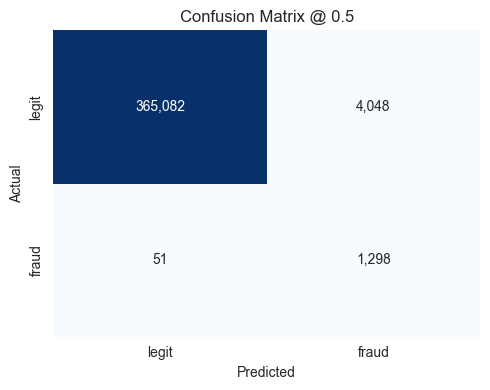

In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=["legit", "fraud"],
    yticklabels=["legit", "fraud"],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix @ 0.5")
plt.tight_layout()
plt.show()

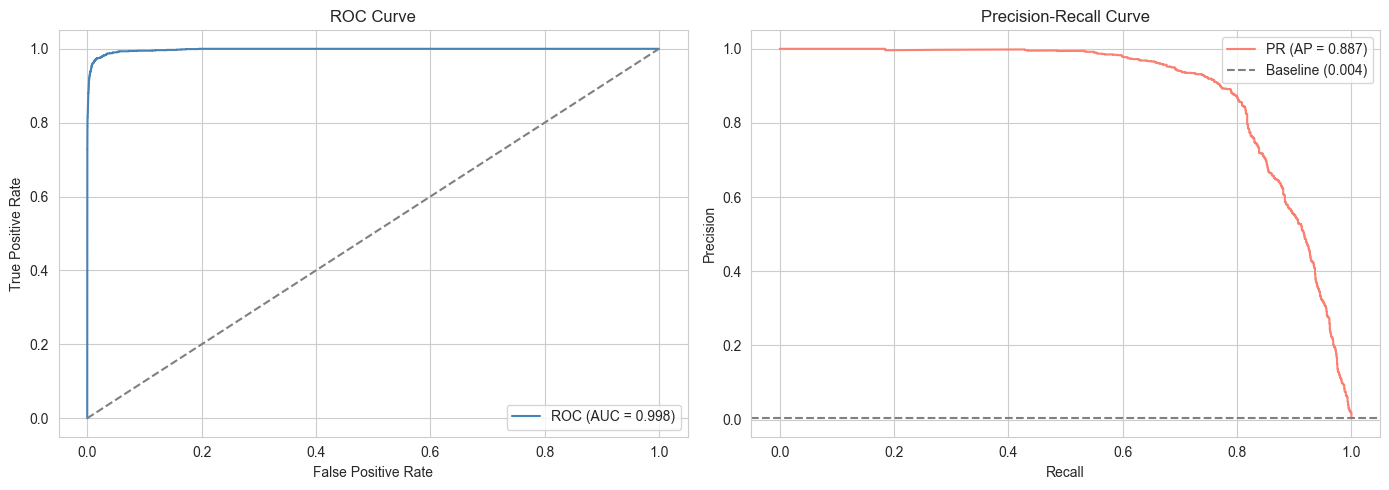

In [9]:
# ROC and Precision-Recall curves
fpr, tpr, _ = roc_curve(y_test, y_proba)
prec, rec, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color="steelblue", label=f"ROC (AUC = {roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].plot(rec, prec, color="salmon", label=f"PR (AP = {pr_auc:.3f})")
axes[1].axhline(y_test.mean(), ls="--", color="gray", label=f"Baseline ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Feature importance

Which of the six minimal features the baseline leans on. Expect `amt` to dominate, with `category` and `hour` contributing — consistent with the EDA.

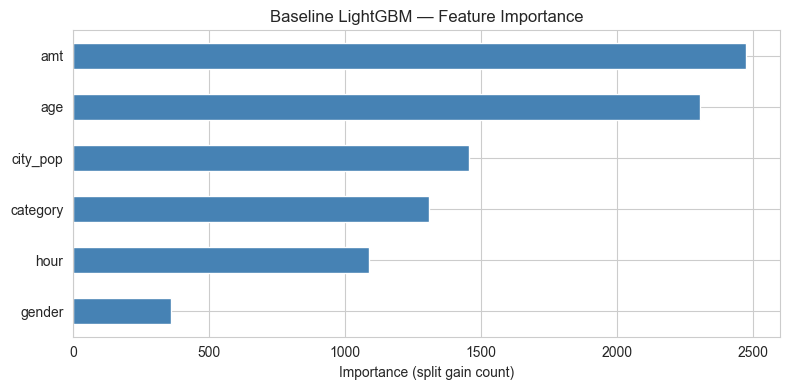

amt         2477
age         2308
city_pop    1455
category    1311
hour        1087
gender       362


In [10]:
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot.barh(ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Importance (split gain count)")
ax.set_title("Baseline LightGBM — Feature Importance")
plt.tight_layout()
plt.show()

print(importance.sort_values(ascending=False).to_string())

## Summary

This baseline uses six leakage-free features and `scale_pos_weight = n_neg / n_pos` to counter the ~0.5% fraud rate. The **PR-AUC** here is the number to beat in the feature-engineering phase (spending velocity, geo-distance, deviation from a card's normal spend).

Next steps:
- Engineer behavioural features and re-measure against this PR-AUC.
- Tune the decision threshold to a business-driven precision/recall target.
- Add SHAP explanations for individual predictions.